In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,plot_confusion_matrix
from sklearn.tree import *
from sklearn.model_selection import *
from sklearn.preprocessing import *
from sklearn.ensemble import *
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import *
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


# Importing Data

In [2]:
train_df = pd.read_csv(r"../input/titanic/train.csv")
test_df = pd.read_csv(r'../input/titanic/test.csv')
IDtest = test_df['PassengerId']

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

In [5]:
train_df.shape

(891, 12)

Distribution of Numerical features

In [6]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Distribution of Categorical  features

In [7]:
train_df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [8]:
train_df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


Checking For Null Values in Data

In [9]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Checking For Duplicate Values in data

In [11]:
print("Number of Duplicated rows in training set "  ,train_df.duplicated().sum())
print("Number of Duplicated rows in testing set "  ,test_df.duplicated().sum())

Number of Duplicated rows in training set  0
Number of Duplicated rows in testing set  0


# EDA

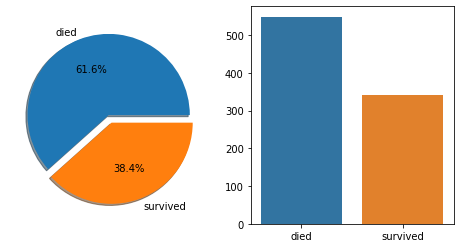

In [12]:
f,ax=plt.subplots(1,2,figsize=(8,4))
train_df['Survived'].replace({0:"died",1:"survived"}).value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_ylabel('')
sns.countplot(x = train_df["Survived"].replace({0:"died",1:"survived"}) , ax = ax[1])
ax[1].set_ylabel('')
ax[1].set_xlabel('')
plt.show()

In [13]:
def survived_bar_plot(feature):
    plt.figure(figsize = (6,4))
    sns.barplot(data = train_df , x = feature , y = "Survived").set_title(f"{feature} Vs Survived")
    plt.show()
def survived_table(feature):
    return train_df[[feature, "Survived"]].groupby([feature], as_index=False).mean().sort_values(by='Survived', ascending=False).style.background_gradient(low=0.75,high=1)
def survived_hist_plot(feature):
    plt.figure(figsize = (6,4))
    sns.histplot(data = train_df , x = feature , hue = "Survived",binwidth=5,palette = sns.color_palette(["yellow" , "green"]) ,multiple = "stack" ).set_title(f"{feature} Vs Survived")
    plt.show()

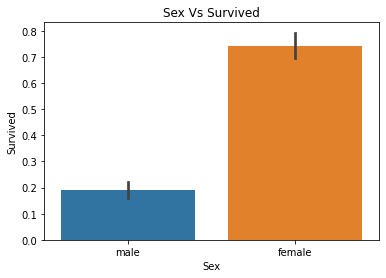

In [14]:
survived_bar_plot('Sex')

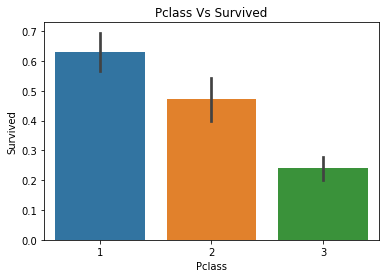

In [15]:
survived_bar_plot("Pclass")

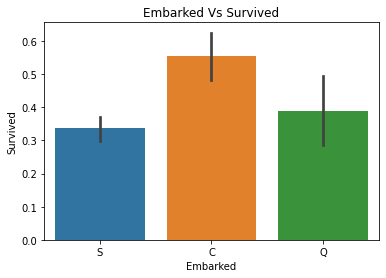

In [16]:
survived_bar_plot("Embarked")

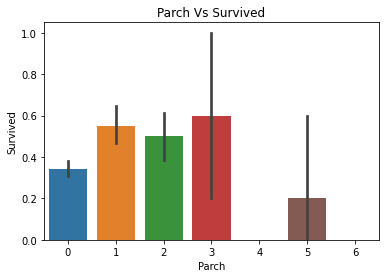

In [17]:
survived_bar_plot("Parch")

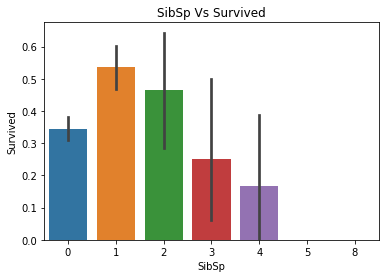

In [18]:
survived_bar_plot("SibSp")

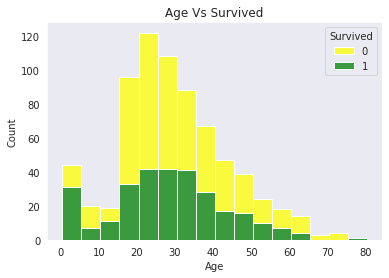

In [19]:
sns.set_style("dark") 
survived_hist_plot("Age") 

# Data Wrangling

Dropping Unusefull Features

In [20]:
train_df.drop(['Name', 'PassengerId', 'Ticket', 'Cabin'], axis=1, inplace=True)
test_df.drop(['Name', 'PassengerId', 'Ticket' ,'Cabin'], axis=1, inplace=True)

Embarked Column in Training Set

In [21]:
train_df[train_df['Embarked'].isnull()]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
61,1,1,female,38.0,0,0,80.0,NaN
829,1,1,female,62.0,0,0,80.0,NaN


Its Observed that null values in Embarked Column matches with Pclass=1 , So we'll find the most frequent Embarked value in pclass=1 and replace with it.

In [22]:
train_df.groupby(['Pclass'])['Embarked'].agg(lambda x:x.value_counts().index[0])

Pclass
1    S
2    S
3    S
Name: Embarked, dtype: object

In [23]:
train_df['Embarked'] = train_df.Embarked.fillna('S')

Fare Column in Testing Set
<br>
We'll Replace the missing values with the Mean value

In [24]:
test_df['Fare'] = test_df.Fare.fillna(test_df.Fare.dropna().mean())

Age Value in Both Training and Testing Set
<br> 
We'll replace missing values with the median age value in the same (Pclass , Sex Gender)

In [25]:
train_df[["Pclass" ,"Sex", "Age"]].groupby(['Sex', 'Pclass'], as_index=False).median()

,Sex,Pclass,Age
0,female,1,35.0
1,female,2,28.0
2,female,3,21.5
3,male,1,40.0
4,male,2,30.0
5,male,3,25.0


In [28]:
combine=[train_df, test_df]
for df in combine:
    for i in df.index:
        if(pd.isnull(df['Age'][i])):
            df['Age'][i] = train_df[(train_df['Sex'] == df['Sex'][i]) & (train_df['Pclass'] == df['Pclass'][i])]['Age'].dropna().median()
    df['Age'] = df['Age'].astype(int)

In [29]:
train_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [30]:
test_df.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [31]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 55.8+ KB


# Splitting Data

We'll use OnehotEncoding to Encode Categorical Data 

In [32]:
features = ["Pclass" , "Sex" , "Age" , "SibSp" , "Parch" , "Fare" , "Embarked"]

X_train = pd.get_dummies(train_df[features])
Y_train = train_df["Survived"]
X_test = pd.get_dummies(test_df[features])

X_train.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22,1,0,7.2500,0,1,0,0,1
1,1,38,1,0,71.2833,1,0,1,0,0
2,3,26,0,0,7.9250,1,0,0,0,1
3,1,35,1,0,53.1000,1,0,0,0,1
4,3,35,0,0,8.0500,0,1,0,0,1


In [33]:
print(X_train.shape , " " ,X_test.shape)

(891, 10)   (418, 10)


In [34]:
sc=RobustScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

# Modeling

We'll Try different Algorithms and pick the best one.

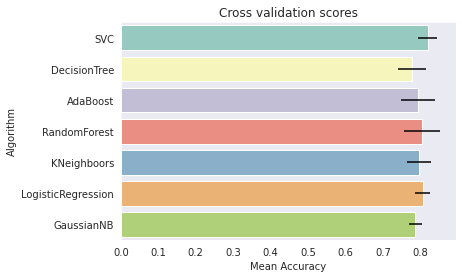

In [35]:
random_state = 2
kfold = StratifiedKFold(n_splits=10)
classifiers = []
classifiers.append(SVC(random_state=random_state))
classifiers.append(DecisionTreeClassifier(random_state=random_state))
classifiers.append(AdaBoostClassifier(DecisionTreeClassifier(random_state=random_state),random_state=random_state,learning_rate=0.1))
classifiers.append(RandomForestClassifier(random_state=random_state))
classifiers.append(KNeighborsClassifier())
classifiers.append(LogisticRegression(random_state = random_state))
classifiers.append(GaussianNB())

cv_results = []
for classifier in classifiers :
    cv_results.append(cross_val_score(classifier, X_train, y = Y_train, scoring = "accuracy", cv = kfold,n_jobs=4))

cv_means = []
cv_std = []
for cv_result in cv_results:
    cv_means.append(cv_result.mean())
    cv_std.append(cv_result.std())

cv_res = pd.DataFrame({"CrossValMeans":cv_means,"CrossValerrors": cv_std,"Algorithm":["SVC","DecisionTree","AdaBoost",
"RandomForest","KNeighboors","LogisticRegression" ,"GaussianNB"]})

g = sns.barplot(data=cv_res ,x="CrossValMeans",y="Algorithm", palette="Set3",orient = "h",**{'xerr':cv_std})
g.set_xlabel("Mean Accuracy")
g = g.set_title("Cross validation scores")

# Hyper Parameter Tuning On Random Forest Algorithm

In [36]:
RFC = RandomForestClassifier()


## Search grid for optimal parameters
rf_param_grid = {"max_depth": [2,5,7],
              "max_features": [1, 5, 8],
              "min_samples_split": [2, 3, 5],
              "min_samples_leaf": [1, 3, 10],
              "n_estimators" :[50.80,150,300],
              "criterion": ["gini"]}
gsRFC = GridSearchCV(RFC,param_grid = rf_param_grid, cv=kfold, scoring="accuracy", n_jobs= -1, verbose = False)
gsRFC.fit(X_train,Y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
810 fits failed out of a total of 2430.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
810 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_forest.py", line 392, in fit
    self._validate_estimator()
  File "/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_base.py", line 133, in _validate_estimator
    type(self.n_estimators)
ValueError: n_estimators must be an integer, got <cla

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini'], 'max_depth': [2, 5, 7],
                         'max_features': [1, 5, 8],
                         'min_samples_leaf': [1, 3, 10],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [50.8, 150, 300]},
             scoring='accuracy', verbose=False)

In [37]:
gsRFC.best_params_

{'criterion': 'gini',
 'max_depth': 7,
 'max_features': 5,
 'min_samples_leaf': 3,
 'min_samples_split': 3,
 'n_estimators': 150}

In [38]:
model = RandomForestClassifier(n_estimators= 150 ,max_depth=7 , max_features=8 ,min_samples_split=3 ,min_samples_leaf=1 ,random_state=7)
model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=7, max_features=8, min_samples_split=3,
                       n_estimators=150, random_state=7)

# Submission File

In [40]:
predictions=model.predict(X_test)
output = pd.DataFrame({'PassengerId': IDtest, 'Survived': predictions})
output.to_csv('Titanic_RF.csv', index=False)